<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 50px 40px; border-radius: 16px; text-align: center; margin-bottom: 10px;">
  <h1 style="color: #e94560; font-size: 2.4em; margin: 0 0 10px 0; letter-spacing: 2px;">LightGCN</h1>
  <h2 style="color: #ffffff; font-size: 1.4em; font-weight: 300; margin: 0 0 20px 0;">Système de Recommandation par Réseaux de Neurones Convolutifs pour Graphes</h2>
  <hr style="border: 1px solid #e94560; width: 60%; margin: 20px auto;">
  <p style="color: #a8b2d8; font-size: 1.05em; margin: 6px 0;">Cours : Intelligence Artificielle et Applications</p>
  <p style="color: #a8b2d8; font-size: 1.05em; margin: 6px 0;"> École Nationale Supérieure Polytechnique de Yaoundé</p>
  <p style="color: #a8b2d8; font-size: 1.05em; margin: 6px 0;"> Année académique 2025–2026 · Ingénierie ANI-IA 4</p>
  <p style="color: #ccd6f6; font-size: 0.95em; margin-top: 20px; font-style: italic;">Dataset : MovieLens · Framework : PyTorch · Métrique : Recall@K, NDCG@K</p>
</div>


##  Table des matières

| # | Étape | Description |
|---|-------|-------------|
| 1 | [Contexte & Théorie](#section1) | Introduction à LightGCN et aux systèmes de recommandation |
| 2 | [Installation & Imports](#section2) | Dépendances et configuration de l'environnement |
| 3 | [Chargement des données](#section3) | Téléchargement et exploration de MovieLens |
| 4 | [Préparation des données](#section4) | Nettoyage, réindexation, train/test split |
| 5 | [Construction du graphe](#section5) | Matrice d'adjacence normalisée |
| 6 | [Modèle LightGCN](#section6) | Implémentation complète en PyTorch |
| 7 | [Dataset BPR & Entraînement](#section7) | Perte BPR et boucle d'entraînement |
| 8 | [Évaluation](#section8) | Recall@K et NDCG@K |
| 9 | [Visualisations](#section9) | Courbes, graphe, analyse des embeddings |
| 10 | [Recommandations Top-K](#section10) | Génération et interprétation des résultats |

---

<a id='section1'></a>
## 1. Contexte Théorique

### 1.1 Qu'est-ce qu'un système de recommandation ?

Un système de recommandation prédit les préférences d'un utilisateur pour des items qu'il n'a pas encore vus.  
L'approche **filtrage collaboratif** exploite les interactions passées : *"les utilisateurs qui ont aimé les mêmes films que toi ont aussi aimé X"*.

### 1.2 Pourquoi les Graphes ?

Les interactions utilisateur-item forment naturellement un **graphe biparti** :
- Les **nœuds** sont les utilisateurs et les items
- Les **arêtes** représentent les interactions (vues, notes, achats...)

```
Utilisateurs          Films
   Alice  ──────────  Inception
   Alice  ─────────── Matrix
   Bob    ──────────  Matrix  
   Bob    ─────────── Avengers
```

### 1.3 LightGCN — Formulation mathématique

**LightGCN** (He et al., 2020) simplifie les GCN traditionnels en supprimant la transformation linéaire et la non-linéarité à chaque couche.

#### Propagation d'embeddings (couche k → k+1) :

$$\mathbf{e}_u^{(k+1)} = \sum_{i \in \mathcal{N}(u)} \frac{1}{\sqrt{|\mathcal{N}(u)|}\sqrt{|\mathcal{N}(i)|}} \mathbf{e}_i^{(k)}$$

$$\mathbf{e}_i^{(k+1)} = \sum_{u \in \mathcal{N}(i)} \frac{1}{\sqrt{|\mathcal{N}(i)|}\sqrt{|\mathcal{N}(u)|}} \mathbf{e}_u^{(k)}$$

#### Agrégation finale (moyenne sur K couches) :

$$\mathbf{e}_u^* = \frac{1}{K+1} \sum_{k=0}^{K} \mathbf{e}_u^{(k)}, \quad \mathbf{e}_i^* = \frac{1}{K+1} \sum_{k=0}^{K} \mathbf{e}_i^{(k)}$$

#### Score de prédiction :

$$\hat{y}_{ui} = {\mathbf{e}_u^*}^\top \mathbf{e}_i^*$$

#### Perte BPR (Bayesian Personalized Ranking) :

$$\mathcal{L}_{BPR} = -\sum_{(u,i,j) \in \mathcal{O}} \ln \sigma(\hat{y}_{ui} - \hat{y}_{uj}) + \lambda \|\Theta\|^2$$

Où $(u, i, j)$ est un triplet : $u$ = utilisateur, $i$ = item positif (vu), $j$ = item négatif (non vu).

### 1.4 Métriques d'évaluation

| Métrique | Formule | Interprétation |
|----------|---------|----------------|
| **Recall@K** | $\frac{|\text{items pertinents dans Top-K}|}{|\text{total items pertinents}|}$ | Taux de rappel dans les K meilleures recommandations |
| **NDCG@K** | $\frac{DCG@K}{IDCG@K}$ |Score normalisé (0 à 1) mesurant la qualité du classement : items pertinents doivent être en tête |

Recall@K : c est le taux de rappel dans les K meilleures recommandations

C'est simple : sur tous les items pertinents qui existent, combien en retrouvez-vous dans les K premières recommandations ?
* DCG@K = Discounted Cumulative Gain (gain actualisé)
* IDCG@K = Ideal DCG (DCG du classement parfait)

<a id='section2'></a>
## 2. Installation et Imports

In [1]:
# Installation des dépendances (décommenter si nécessaire)
!pip install torch pandas numpy scipy scikit-learn matplotlib seaborn tqdm


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ── Imports standard ──────────────────────────────────────────────────────────
import os
import zipfile
import urllib.request
import warnings
warnings.filterwarnings('ignore')

# ── Manipulation de données ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.model_selection import train_test_split

# ── Deep Learning ──────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Utilitaires ───────────────────────────────────────────────────────────────
import time
import random
from collections import defaultdict

# ── Configuration globale ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})
sns.set_palette("husl")

# ── Reproductibilité ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ─────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Environnement prêt")
print(f"   Device : {DEVICE}")
print(f"   PyTorch : {torch.__version__}")
print(f"   NumPy   : {np.__version__}")
print(f"   Pandas  : {pd.__version__}")

 Environnement prêt
   Device : cpu
   PyTorch : 2.9.1+cpu
   NumPy   : 2.2.6
   Pandas  : 2.3.3


<a id='section3'></a>
## 3. Chargement et Exploration du Dataset MovieLens

MovieLens est le dataset de référence pour les systèmes de recommandation.  
Nous utilisons **ml-latest-small** : ~100 000 notations, 610 utilisateurs, 9 724 films.

In [3]:
def download_movielens(data_dir="data"):
    """Télécharge et extrait MovieLens small s'il n'est pas déjà présent."""
    os.makedirs(data_dir, exist_ok=True)
    extract_path = os.path.join(data_dir, "ml-latest-small")

    if not os.path.exists(extract_path):
        url      = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
        zip_path = os.path.join(data_dir, "ml-latest-small.zip")
        print("  Téléchargement de MovieLens en cours...")
        urllib.request.urlretrieve(url, zip_path)
        print(" Extraction...")
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(data_dir)
        os.remove(zip_path)
        print(" Dataset téléchargé et extrait.")
    else:
        print(" Dataset déjà présent.")

    return extract_path

DATA_PATH = download_movielens("data")
print(f"\n Dossier : {DATA_PATH}")
print(f"   Fichiers : {os.listdir(DATA_PATH)}")

 Dataset déjà présent.

 Dossier : data\ml-latest-small
   Fichiers : ['links.csv', 'movies.csv', 'ratings.csv', 'README.txt', 'tags.csv']


### 3.1 Chargement  du dataset movies.csv et ratings.csv

In [4]:
# ── Chargement des fichiers ────────────────────────────────────────────────────
ratings_df = pd.read_csv(os.path.join(DATA_PATH, "ratings.csv"))
movies_df  = pd.read_csv(os.path.join(DATA_PATH, "movies.csv"))

print("═" * 55)
print("  APERÇU DU DATASET MOVIELENS")
print("═" * 55)
print(f"\n ratings.csv  → {ratings_df.shape[0]:,} lignes, {ratings_df.shape[1]} colonnes")
print(f" movies.csv   → {movies_df.shape[0]:,} films")

print(f"  Utilisateurs uniques : {ratings_df['userId'].nunique():,}")
print(f"  Films uniques        : {ratings_df['movieId'].nunique():,}")
print(f"  Note minimale        : {ratings_df['rating'].min()}")
print(f"  Note maximale        : {ratings_df['rating'].max()}")
print(f"  Note moyenne         : {ratings_df['rating'].mean():.2f}")

═══════════════════════════════════════════════════════
  APERÇU DU DATASET MOVIELENS
═══════════════════════════════════════════════════════

 ratings.csv  → 100,836 lignes, 4 colonnes
 movies.csv   → 9,742 films
  Utilisateurs uniques : 610
  Films uniques        : 9,724
  Note minimale        : 0.5
  Note maximale        : 5.0
  Note moyenne         : 3.50


### Pourquoi utiliser `ratings.csv` et `movies.csv` ?

Dans ce TP, les deux fichiers jouent des rôles différents mais complémentaires :

- `ratings.csv` contient les interactions utilisateur-film. C’est la base de l’entraînement de LightGCN, car le modèle apprend à partir de qui a noté quoi.
- `movies.csv` contient les informations descriptives des films. Il ne sert pas à apprendre les préférences directement, mais il permet d’identifier les films, d’afficher leurs titres et d’exploiter les genres pour l’analyse.

En pratique, on utilise donc :

1. `ratings.csv` pour construire le graphe biparti utilisateur-item et entraîner le modèle.
2. `movies.csv` pour relier les identifiants internes aux titres lisibles et enrichir l’interprétation des recommandations.

Cela signifie que le vrai signal d’apprentissage vient de `ratings.csv`, tandis que `movies.csv` sert surtout à rendre les résultats compréhensibles et à préparer d’éventuelles extensions hybrides du système.

In [5]:
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


### Interprétation des colonnes de `movies_df`

> Source : `ml-latest-small/movies.csv` téléchargé et extrait depuis MovieLens.

| Colonne | Signification | Rôle dans le projet |
|---|---|---|
| `movieId` | Identifiant unique du film dans MovieLens | Sert de clé pour relier les films aux interactions de `ratings.csv` et pour créer les index internes du modèle |
| `title` | Titre du film, souvent avec l’année de sortie | Permet d’afficher des recommandations lisibles par l’utilisateur |
| `genres` | Genres du film séparés par `|` (ex. `Adventure|Comedy`) | Peut être converti en liste pour de futures analyses ou pour un modèle hybride |

### Pourquoi ce fichier est prêt pour l'entraînement

- `movieId` est la colonne de jointure principale avec les notations.
- `title` sert surtout à l’interprétation des résultats, pas à l’apprentissage direct.
- `genres` enrichit l’analyse descriptive et peut être exploité si on ajoute des features de contenu.

Dans la suite du TP, on transforme `genres` en liste puis on peut indexer `movieId` pour préparer les données du modèle LightGCN.

In [6]:
movies_df['genres'] = movies_df['genres'].apply(lambda x: x.split('|'))
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),[Comedy]


#### on supprime premiere colonne du dataset 

In [7]:
movies_df.set_index('movieId', inplace=True)
movies_df.head()

,title,genres
movieId,,
1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
2,Jumanji (1995),"[Adventure, Children, Fantasy]"
3,Grumpier Old Men (1995),"[Comedy, Romance]"
4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]"
5,Father of the Bride Part II (1995),[Comedy]


In [8]:
movies_df.shape

(9742, 2)

In [9]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9742 entries, 1 to 193609
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   9742 non-null   object
 1   genres  9742 non-null   object
dtypes: object(2)
memory usage: 228.3+ KB


### 3.1.2 `ratings.csv`

> Ce fichier est le plus important pour l’entraînement du modèle.

Dans un système de recommandation, on cherche à comprendre les liens entre un utilisateur et un film.
C’est exactement ce que contient `ratings.csv` : les notes données par les utilisateurs.

On y trouve généralement :

- `userId` : l’identifiant de l’utilisateur
- `movieId` : l’identifiant du film
- `rating` : la note attribuée
- `timestamp` : la date de la notation

Pour LightGCN, `ratings.csv` sert à construire les interactions du graphe biparti utilisateur-film.
C’est donc le vrai signal d’apprentissage.

À côté de ça, `movies.csv` sert surtout à donner du sens aux résultats.
Il permet de retrouver le titre du film à partir de `movieId` et d’afficher les recommandations de façon lisible.

En résumé :

- `ratings.csv` apprend au modèle qui aime quoi
- `movies.csv` aide à interpréter les résultats et à afficher les titres

In [10]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [11]:
ratings_df.shape

(100836, 4)

In [12]:
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [13]:
ratings_df.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [14]:
ratings_df.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [15]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


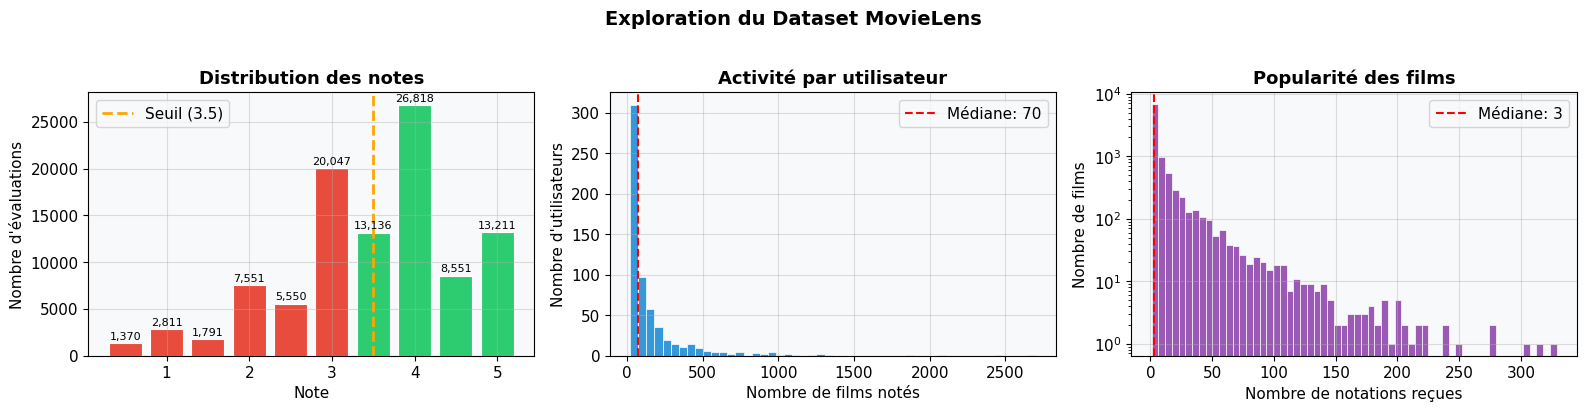

Visualisation sauvegardée.


In [16]:
# ── Visualisation exploratoire ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Exploration du Dataset MovieLens", fontsize=14, fontweight='bold', y=1.02)

# Distribution des notes
ax1 = axes[0]
note_counts = ratings_df['rating'].value_counts().sort_index()
bars = ax1.bar(note_counts.index, note_counts.values,
               color=['#e74c3c' if x < 3.5 else '#2ecc71' for x in note_counts.index],
               width=0.4, edgecolor='white', linewidth=0.8)
ax1.set_title("Distribution des notes")
ax1.set_xlabel("Note")
ax1.set_ylabel("Nombre d'évaluations")
ax1.axvline(x=3.5, color='orange', linestyle='--', linewidth=2, label='Seuil (3.5)')
ax1.legend()
for bar, val in zip(bars, note_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,}', ha='center', va='bottom', fontsize=8)

# Nombre d'interactions par utilisateur
ax2 = axes[1]
user_activity = ratings_df.groupby('userId').size()
ax2.hist(user_activity, bins=50, color='#3498db', edgecolor='white', linewidth=0.5)
ax2.set_title("Activité par utilisateur")
ax2.set_xlabel("Nombre de films notés")
ax2.set_ylabel("Nombre d'utilisateurs")
ax2.axvline(user_activity.median(), color='red', linestyle='--',
            label=f'Médiane: {user_activity.median():.0f}')
ax2.legend()

# Popularité des films
ax3 = axes[2]
item_popularity = ratings_df.groupby('movieId').size()
ax3.hist(item_popularity, bins=60, color='#9b59b6', edgecolor='white', linewidth=0.5)
ax3.set_title("Popularité des films")
ax3.set_xlabel("Nombre de notations reçues")
ax3.set_ylabel("Nombre de films")
ax3.set_yscale('log')
ax3.axvline(item_popularity.median(), color='red', linestyle='--',
            label=f'Médiane: {item_popularity.median():.0f}')
ax3.legend()

plt.tight_layout()
plt.savefig("exploration_movielens.png", dpi=150, bbox_inches='tight')
plt.show()
print("Visualisation sauvegardée.")

### Interprétation du graphe

Ce graphique montre que le dataset MovieLens est très déséquilibré et très creux.

- La majorité des notes se situe au-dessus du seuil 3.5, donc on garde surtout les interactions positives pour l’entraînement.
- Quelques utilisateurs notent beaucoup de films, mais la plupart en notent peu : cela crée une forte disparité d’activité.
- Quelques films sont très populaires, alors qu’une grande partie reçoit très peu de notations : c’est l’effet de longue traîne.

En résumé, ces distributions confirment que le problème de recommandation est difficile et sparse. C’est précisément pour ce type de données que LightGCN est adapté, car il apprend à partir des relations du graphe utilisateur-film plutôt que d’une simple table dense.

<a id='section4'></a>
## 4. Préparation des Données

### Stratégie
1. **Binarisation** : noter (rating) ≥ 3.5 → interaction positive (1), sinon ignorée
2. **Réindexation** : IDs continus de 0 à N-1 (requis par les embeddings PyTorch)
3. **Split train/test** : 80% / 20% par utilisateur (stratifié)

In [17]:
# ── 4.1  Binarisation ─────────────────────────────────────────────────────────
print("ÉTAPE 4.1 — Binarisation des interactions")
print("-" * 45)

df = ratings_df.copy()
# Reset the index to ensure 'userId' is a column for subsequent operations.
df = df.reset_index()

before = len(df)
df = df[df['rating'] >= 3.5][['userId', 'movieId']].copy()
after  = len(df)

print(f"Interactions avant filtre : {before:,}")
print(f"Interactions après filtre : {after:,}  (notes ≥ 3.5)")
print(f"Interactions filtrées     : {before - after:,} ({(before-after)/before*100:.1f}%)")
print(f"Ratio de conservation     : {after/before*100:.1f}%")

ÉTAPE 4.1 — Binarisation des interactions
---------------------------------------------
Interactions avant filtre : 100,836
Interactions après filtre : 61,716  (notes ≥ 3.5)
Interactions filtrées     : 39,120 (38.8%)
Ratio de conservation     : 61.2%


In [18]:
# ── 4.2  Réindexation ─────────────────────────────────────────────────────────
print("ÉTAPE 4.2 — Réindexation des IDs")
print("-" * 45)

users_unique = df['userId'].unique()
items_unique = df['movieId'].unique()

user2idx = {u: i for i, u in enumerate(sorted(users_unique))}
item2idx = {m: i for i, m in enumerate(sorted(items_unique))}
idx2user = {i: u for u, i in user2idx.items()}
idx2item = {i: m for m, i in item2idx.items()}

df['user'] = df['userId'].map(user2idx)
df['item'] = df['movieId'].map(item2idx)
df = df[['user', 'item']].drop_duplicates().reset_index(drop=True)

N_USERS = len(user2idx)
N_ITEMS = len(item2idx)
DENSITY = len(df) / (N_USERS * N_ITEMS) * 100

print(f"Nombre d'utilisateurs (N) : {N_USERS}")
print(f"Nombre de films (M)       : {N_ITEMS}")
print(f"Interactions uniques      : {len(df):,}")
print(f"Densité de la matrice     : {DENSITY:.4f}%  ← très creuse (normal)")
print(f"\nSample :")
print(df.head(5).to_string(index=False))

ÉTAPE 4.2 — Réindexation des IDs
---------------------------------------------
Nombre d'utilisateurs (N) : 609
Nombre de films (M)       : 7363
Interactions uniques      : 61,716
Densité de la matrice     : 1.3763%  ← très creuse (normal)

Sample :
 user  item
    0     0
    0     2
    0     4
    0    41
    0    43


In [19]:
# ── 4.3  Split Train / Test ────────────────────────────────────────────────────
print("ÉTAPE 4.3 — Séparation Train / Test")
print("-" * 45)

train_list, test_list = [], []

for uid, group in df.groupby('user'):
    items = group['item'].tolist()
    if len(items) < 5:
        train_list.append(pd.DataFrame({'user': uid, 'item': items}))
        continue
    n_test = max(1, int(len(items) * 0.2))
    np.random.shuffle(items)
    test_items  = items[:n_test]
    train_items = items[n_test:]
    train_list.append(pd.DataFrame({'user': uid, 'item': train_items}))
    test_list.append( pd.DataFrame({'user': uid, 'item': test_items}))

train_df = pd.concat(train_list, ignore_index=True)
test_df  = pd.concat(test_list,  ignore_index=True)

# Dictionnaire test pour l'évaluation
test_dict = defaultdict(list)
for _, row in test_df.iterrows():
    test_dict[int(row['user'])].append(int(row['item']))

# Items positifs par utilisateur (pour le negative sampling)
user_pos_items = defaultdict(set)
for _, row in train_df.iterrows():
    user_pos_items[int(row['user'])].add(int(row['item']))

print(f"Train : {len(train_df):,} interactions")
print(f"Test  : {len(test_df):,}  interactions")
print(f"Utilisateurs avec données test : {len(test_dict)}")
print(f"Ratio effectif train/test      : {len(train_df)/len(test_df):.1f}x")

ÉTAPE 4.3 — Séparation Train / Test
---------------------------------------------
Train : 49,619 interactions
Test  : 12,097  interactions
Utilisateurs avec données test : 604
Ratio effectif train/test      : 4.1x


<a id='section5'></a>
## 5. Construction du Graphe Biparti et de la Matrice d'Adjacence

La matrice d'adjacence normalisée $\tilde{A}$ est la pièce centrale de LightGCN.

$$A = \begin{pmatrix} 0 & R \\ R^\top & 0 \end{pmatrix}, \quad \tilde{A} = D^{-1/2} A D^{-1/2}$$

où $R \in \{0,1\}^{N \times M}$ est la matrice d'interaction utilisateur-item.

In [20]:
# ── 5.1  Matrice d'interaction R ───────────────────────────────────────────────
print("ÉTAPE 5.1 — Construction de la matrice d'interaction R")
print("-" * 55)

rows_r = train_df['user'].values
cols_r = train_df['item'].values
data_r = np.ones(len(rows_r), dtype=np.float32)

R = sparse.csr_matrix(
    (data_r, (rows_r, cols_r)),
    shape=(N_USERS, N_ITEMS)
)

print(f"Matrice R : {R.shape[0]} × {R.shape[1]}")
print(f"Éléments non-nuls : {R.nnz:,}")
print(f"Mémoire (format sparse) : {R.data.nbytes / 1024:.1f} KB")

ÉTAPE 5.1 — Construction de la matrice d'interaction R
-------------------------------------------------------
Matrice R : 609 × 7363
Éléments non-nuls : 49,619
Mémoire (format sparse) : 193.8 KB


In [21]:
# ── 5.2  Matrice d'adjacence normalisée ───────────────────────────────────────
print("ÉTAPE 5.2 — Construction de la matrice Ã = D^(-1/2) A D^(-1/2)")
print("-" * 60)

N = N_USERS + N_ITEMS

# Construire A symétrique par blocs
zeros_uu = sparse.csr_matrix((N_USERS, N_USERS), dtype=np.float32)
zeros_ii = sparse.csr_matrix((N_ITEMS, N_ITEMS), dtype=np.float32)
upper = sparse.hstack([zeros_uu, R])
lower = sparse.hstack([R.T, zeros_ii])
A     = sparse.vstack([upper, lower]).tocsr().astype(np.float32)

# Degrés et normalisation
degrees     = np.array(A.sum(axis=1)).flatten()
degrees     = np.where(degrees == 0, 1, degrees)
D_inv_sqrt  = sparse.diags(1.0 / np.sqrt(degrees))
A_norm      = (D_inv_sqrt @ A @ D_inv_sqrt).tocoo()

# Conversion en torch sparse
indices = torch.LongTensor(np.vstack([A_norm.row, A_norm.col]))
values  = torch.FloatTensor(A_norm.data)
A_TORCH = torch.sparse_coo_tensor(indices, values, (N, N)).to(DEVICE)

print(f"Matrice A      : {A.shape[0]:,} × {A.shape[1]:,}")
print(f"Matrice Ã      : {A_norm.shape[0]:,} × {A_norm.shape[1]:,}")
print(f"Non-zéros      : {A_norm.nnz:,}")
print(f"Device         : {A_TORCH.device}")
print(f"\n Matrice d'adjacence prête pour LightGCN")

ÉTAPE 5.2 — Construction de la matrice Ã = D^(-1/2) A D^(-1/2)
------------------------------------------------------------
Matrice A      : 7,972 × 7,972
Matrice Ã      : 7,972 × 7,972
Non-zéros      : 99,238
Device         : cpu

 Matrice d'adjacence prête pour LightGCN


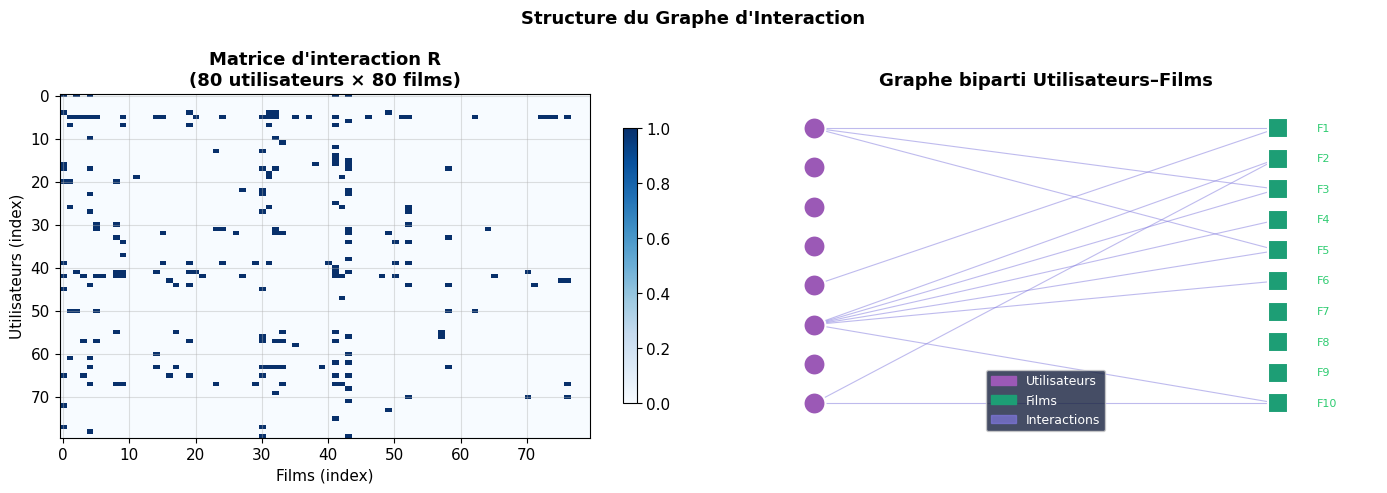

✅ Visualisation du graphe sauvegardée.


In [22]:
# ── 5.3  Visualisation du graphe biparti (sous-échantillon) ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de la matrice R (100 premiers users × 100 premiers items)
ax1 = axes[0]
R_dense = R[:80, :80].toarray()
im = ax1.imshow(R_dense, cmap='Blues', aspect='auto', interpolation='nearest')
ax1.set_title("Matrice d'interaction R\n(80 utilisateurs × 80 films)")
ax1.set_xlabel("Films (index)")
ax1.set_ylabel("Utilisateurs (index)")
plt.colorbar(im, ax=ax1, shrink=0.8)

# Visualisation réseau biparti (petit échantillon)
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('white')

n_u_show, n_i_show = 8, 10
sample_u = list(range(n_u_show))
sample_i = list(range(n_i_show))

# Positions
u_pos = {u: (0.15, 0.9 - u * (0.8 / (n_u_show-1))) for u in sample_u}
i_pos = {i: (0.85, 0.9 - i * (0.8 / (n_i_show-1))) for i in sample_i}

# Tracer les arêtes
R_sub = R[np.ix_(sample_u, sample_i)].toarray()
for u in sample_u:
    for i in sample_i:
        if R_sub[u, i] > 0:
            ax2.plot([u_pos[u][0], i_pos[i][0]],
                     [u_pos[u][1], i_pos[i][1]],
                     color='#7F77DD', alpha=0.5, linewidth=0.8, zorder=1)

# Tracer les nœuds
for u, (x, y) in u_pos.items():
    ax2.scatter(x, y, s=250, c='#9b59b6', zorder=3, edgecolors='white', linewidths=1.5)
    ax2.text(x - 0.06, y, f'U{u+1}', color='white', fontsize=8,
             ha='right', va='center', fontweight='bold')
for i, (x, y) in i_pos.items():
    ax2.scatter(x, y, s=200, c='#1D9E75', zorder=3, marker='s',
                edgecolors='white', linewidths=1.5)
    ax2.text(x + 0.06, y, f'F{i+1}', color='#2ecc71', fontsize=8,
             ha='left', va='center')

ax2.set_facecolor('#1a1a2e')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')
ax2.set_title("Graphe biparti Utilisateurs–Films", color='black')

p1 = mpatches.Patch(color='#9b59b6', label='Utilisateurs')
p2 = mpatches.Patch(color='#1D9E75', label='Films')
p3 = mpatches.Patch(color='#7F77DD', alpha=0.7, label='Interactions')
ax2.legend(handles=[p1,p2,p3], loc='lower center',
           facecolor='#16213e', labelcolor='white', fontsize=9)

plt.suptitle("Structure du Graphe d'Interaction", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("graphe_biparti.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisation du graphe sauvegardée.")

<a id='section6'></a>
## 6. Implémentation du Modèle LightGCN

### Architecture

LightGCN ne contient que des paramètres d'embeddings. Toute l'intelligence vient de la propagation sur le graphe.

```
Entrée : IDs utilisateur / film
   ↓
Embeddings initiaux e⁰_u, e⁰_i  (nn.Embedding)
   ↓
K couches de propagation : e^(k+1) = Ã · e^(k)
   ↓
Agrégation : e* = moyenne(e⁰, e¹, ..., eᴷ)
   ↓
Score : ŷ_ui = e*_u · e*_i
```

In [23]:
class LightGCN(nn.Module):
    """
    LightGCN : Light Graph Convolution Network pour la recommandation.

    Référence : He et al., "LightGCN: Simplifying and Powering Graph
    Convolution Network for Recommendation" (SIGIR 2020).

    Paramètres
    ----------
    n_users     : nombre d'utilisateurs
    n_items     : nombre de films
    embed_dim   : dimension des embeddings (latent factors)
    n_layers    : nombre de couches de propagation K
    A_norm      : matrice d'adjacence normalisée (torch sparse)
    dropout     : taux de dropout sur les embeddings (0 = désactivé)
    """

    def __init__(self, n_users, n_items, embed_dim, n_layers, A_norm, dropout=0.0):
        super(LightGCN, self).__init__()

        self.n_users   = n_users
        self.n_items   = n_items
        self.embed_dim = embed_dim
        self.n_layers  = n_layers
        self.A_norm    = A_norm
        self.dropout   = nn.Dropout(p=dropout)

        # ── Embeddings initiaux (seuls paramètres apprenables) ────────────────
        self.user_embed = nn.Embedding(n_users, embed_dim)
        self.item_embed = nn.Embedding(n_items, embed_dim)

        # ── Initialisation Xavier uniforme ────────────────────────────────────
        nn.init.xavier_uniform_(self.user_embed.weight)
        nn.init.xavier_uniform_(self.item_embed.weight)

    def propagate(self):
        """
        Propagation de messages sur K couches.

        Retourne les embeddings finaux agrégés (moyenne de toutes les couches).
        """
        # Concaténer embeddings utilisateurs et items → vecteur de taille N+M
        E0 = torch.cat([self.user_embed.weight,
                        self.item_embed.weight], dim=0)  # (N+M, d)

        all_embeddings = [E0]
        E = E0

        for _ in range(self.n_layers):
            # Propagation : E^(k+1) = Ã · E^(k)
            E = torch.sparse.mm(self.A_norm, E)
            all_embeddings.append(E)

        # Agrégation par moyenne sur les K+1 couches
        E_final = torch.stack(all_embeddings, dim=1).mean(dim=1)  # (N+M, d)

        # Séparer utilisateurs et items
        user_emb_final = E_final[:self.n_users]
        item_emb_final = E_final[self.n_users:]

        return user_emb_final, item_emb_final

    def forward(self, users, pos_items, neg_items):
        """
        Calcule les scores pour un batch de triplets (u, i+, i-).

        Paramètres
        ----------
        users     : indices utilisateurs  [batch_size]
        pos_items : indices items positifs [batch_size]
        neg_items : indices items négatifs [batch_size]

        Retourne
        --------
        pos_scores, neg_scores : scores prédits pour BPR
        user_emb, pos_emb, neg_emb : embeddings pour la régularisation L2
        """
        user_emb_all, item_emb_all = self.propagate()

        user_emb = user_emb_all[users]
        pos_emb  = item_emb_all[pos_items]
        neg_emb  = item_emb_all[neg_items]

        # Appliquer dropout (régularisation supplémentaire)
        user_emb = self.dropout(user_emb)
        pos_emb  = self.dropout(pos_emb)
        neg_emb  = self.dropout(neg_emb)

        # Scores par produit scalaire
        pos_scores = (user_emb * pos_emb).sum(dim=1)
        neg_scores = (user_emb * neg_emb).sum(dim=1)

        # Embeddings initiaux pour la régularisation L2
        user_emb0 = self.user_embed(users)
        pos_emb0  = self.item_embed(pos_items)
        neg_emb0  = self.item_embed(neg_items)

        return pos_scores, neg_scores, user_emb0, pos_emb0, neg_emb0

    def recommend(self, users):
        """Génère les scores pour tous les items pour un batch d'utilisateurs."""
        user_emb_all, item_emb_all = self.propagate()
        user_emb = user_emb_all[users]           # (batch, d)
        scores   = user_emb @ item_emb_all.T     # (batch, n_items)
        return scores

    def count_parameters(self):
        """Compte le nombre de paramètres apprenables."""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ── Hyperparamètres ────────────────────────────────────────────────────────────
EMBED_DIM = 64
N_LAYERS  = 3
LR        = 1e-3
LAMBDA    = 1e-4  # régularisation L2
EPOCHS    = 30
BATCH_SIZE = 1024

# ── Instanciation du modèle ───────────────────────────────────────────────────
model = LightGCN(
    n_users   = N_USERS,
    n_items   = N_ITEMS,
    embed_dim = EMBED_DIM,
    n_layers  = N_LAYERS,
    A_norm    = A_TORCH,
    dropout   = 0.1
).to(DEVICE)

print("═" * 50)
print("  ARCHITECTURE LIGHTGCN")
print("═" * 50)
print(model)
print(f"\n  Paramètres apprenables : {model.count_parameters():,}")
print(f"  Dim. embedding (d)     : {EMBED_DIM}")
print(f"  Couches GCN (K)        : {N_LAYERS}")
print(f"  Taux dropout           : 0.1")
print(f"  Device                 : {next(model.parameters()).device}")

══════════════════════════════════════════════════
  ARCHITECTURE LIGHTGCN
══════════════════════════════════════════════════
LightGCN(
  (dropout): Dropout(p=0.1, inplace=False)
  (user_embed): Embedding(609, 64)
  (item_embed): Embedding(7363, 64)
)

  Paramètres apprenables : 510,208
  Dim. embedding (d)     : 64
  Couches GCN (K)        : 3
  Taux dropout           : 0.1
  Device                 : cpu


<a id='section7'></a>
## 7. Dataset BPR et Entraînement

### Perte BPR (Bayesian Personalized Ranking)

Pour chaque triplet $(u, i^+, i^-)$, on maximise la différence entre le score de l'item positif et celui de l'item négatif :

$$\mathcal{L} = -\sum \ln \sigma(\hat{y}_{u,i^+} - \hat{y}_{u,i^-}) + \lambda \|\Theta\|^2$$

In [24]:
class BPRDataset(Dataset):
    """
    Dataset générant des triplets (utilisateur, item_positif, item_négatif).

    À chaque appel, un item négatif est tiré aléatoirement parmi les films
    non vus par l'utilisateur — technique dite de 'negative sampling'.
    """

    def __init__(self, train_df, n_items, user_pos_items):
        self.n_items       = n_items
        self.user_pos_items = user_pos_items
        self.pairs = list(zip(
            train_df['user'].values.astype(np.int64),
            train_df['item'].values.astype(np.int64)
        ))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        user, pos_item = self.pairs[idx]

        # Negative sampling : tirer un item non vu
        while True:
            neg_item = np.random.randint(0, self.n_items)
            if neg_item not in self.user_pos_items[user]:
                break

        return (torch.tensor(user,     dtype=torch.long),
                torch.tensor(pos_item, dtype=torch.long),
                torch.tensor(neg_item, dtype=torch.long))


def bpr_loss(pos_scores, neg_scores, user_emb, pos_emb, neg_emb, lambda_reg):
    """
    Calcule la perte BPR avec régularisation L2.

    Paramètres
    ----------
    pos_scores, neg_scores : scores prédits
    user_emb, pos_emb, neg_emb : embeddings initiaux pour L2
    lambda_reg : coefficient de régularisation
    """
    # Perte BPR principale
    bpr = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()

    # Régularisation L2 sur les embeddings initiaux
    reg = lambda_reg * (
        user_emb.norm(2).pow(2) +
        pos_emb.norm(2).pow(2)  +
        neg_emb.norm(2).pow(2)
    ) / pos_scores.size(0)

    return bpr + reg, bpr.item(), reg.item()


# ── Préparation du DataLoader ─────────────────────────────────────────────────
train_dataset = BPRDataset(train_df, N_ITEMS, user_pos_items)
train_loader  = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = True,
    num_workers = 0,
    pin_memory  = (DEVICE.type == 'cuda')
)

print(f"Dataset d'entraînement : {len(train_dataset):,} triplets")
print(f"Batches par époque     : {len(train_loader)}")
print(f"Taille de batch        : {BATCH_SIZE}")

Dataset d'entraînement : 49,619 triplets
Batches par époque     : 49
Taille de batch        : 1024


In [25]:
# ── Fonctions d'évaluation ────────────────────────────────────────────────────
def recall_at_k(recommended, relevant, k):
    """Recall@K : proportion des items pertinents retrouvés dans le Top-K."""
    if not relevant:
        return 0.0
    recommended_k = set(recommended[:k])
    relevant_set  = set(relevant)
    return len(recommended_k & relevant_set) / len(relevant_set)


def ndcg_at_k(recommended, relevant, k):
    """NDCG@K : tient compte de la position des items pertinents."""
    if not relevant:
        return 0.0
    relevant_set = set(relevant)
    dcg  = sum(1.0 / np.log2(rank + 2)
               for rank, item in enumerate(recommended[:k])
               if item in relevant_set)
    idcg = sum(1.0 / np.log2(rank + 2)
               for rank in range(min(k, len(relevant_set))))
    return dcg / idcg if idcg > 0 else 0.0


@torch.no_grad()
def evaluate(model, test_dict, user_pos_items, n_items, k=20, n_eval=500):
    """
    Évalue le modèle sur le test set.

    n_eval : limiter à n_eval utilisateurs pour accélérer l'évaluation
    """
    model.eval()
    recalls, ndcgs = [], []

    test_users = list(test_dict.keys())
    if len(test_users) > n_eval:
        test_users = random.sample(test_users, n_eval)

    batch_size = 128
    for start in range(0, len(test_users), batch_size):
        batch_users = test_users[start:start + batch_size]
        u_tensor    = torch.LongTensor(batch_users).to(DEVICE)
        scores      = model.recommend(u_tensor).cpu().numpy()

        for i, user in enumerate(batch_users):
            # Masquer les items déjà vus à l'entraînement
            for pos in user_pos_items.get(user, []):
                if pos < n_items:
                    scores[i, pos] = -1e9

            top_k     = np.argsort(-scores[i])[:k].tolist()
            relevant  = test_dict.get(user, [])

            recalls.append(recall_at_k(top_k, relevant, k))
            ndcgs.append(  ndcg_at_k(  top_k, relevant, k))

    return np.mean(recalls), np.mean(ndcgs)


print(" Fonctions d'évaluation prêtes (Recall@K et NDCG@K)")

 Fonctions d'évaluation prêtes (Recall@K et NDCG@K)


In [30]:
# ══════════════════════════════════════════════════════════════════════════════
#  BOUCLE D'ENTRAÎNEMENT PRINCIPALE
# ══════════════════════════════════════════════════════════════════════════════

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=0)

# Historique pour les courbes
history = {
    'epoch':   [],
    'loss':    [],
    'bpr':     [],
    'reg':     [],
    'recall':  [],
    'ndcg':    [],
}

best_recall = 0.0
best_epoch  = 0
K_EVAL      = 20

print("═" * 65)
print(f"  ENTRAÎNEMENT LIGHTGCN — {EPOCHS} époques")
print(f"  Éval à chaque epoch sur Top-{K_EVAL}")
print("═" * 65)
print(f"{'Époque':>6} | {'Loss':>8} | {'BPR':>8} | {'Recall@20':>10} | {'NDCG@20':>8}")
print("-" * 65)

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = total_bpr = total_reg = 0.0

    for users, pos_items, neg_items in train_loader:
        users     = users.to(DEVICE)
        pos_items = pos_items.to(DEVICE)
        neg_items = neg_items.to(DEVICE)

        optimizer.zero_grad()
        pos_scores, neg_scores, u_emb, p_emb, n_emb = model(
            users, pos_items, neg_items
        )
        loss, bpr, reg = bpr_loss(
            pos_scores, neg_scores, u_emb, p_emb, n_emb, LAMBDA
        )
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bpr  += bpr
        total_reg  += reg

    avg_loss = total_loss / len(train_loader)
    avg_bpr  = total_bpr  / len(train_loader)
    avg_reg  = total_reg  / len(train_loader)

    history['epoch'].append(epoch)
    history['loss'].append(avg_loss)
    history['bpr'].append(avg_bpr)
    history['reg'].append(avg_reg)

    # Évaluation à chaque epoch
    recall, ndcg = evaluate(model, test_dict, user_pos_items, N_ITEMS, k=K_EVAL)
    history['recall'].append(recall)
    history['ndcg'].append(ndcg)

    marker = "" if recall > best_recall else ""
    if recall > best_recall:
        best_recall = recall
        best_epoch  = epoch
        torch.save(model.state_dict(), "best_lightgcn.pth")

    print(f"  {epoch:4d}  | {avg_loss:8.4f} | {avg_bpr:8.4f} | {recall:10.4f} | {ndcg:8.4f}{marker}")

elapsed = time.time() - start_time
print("═" * 65)
print(f"\n Entraînement terminé en {elapsed:.1f}s")
print(f"   Meilleur Recall@20 : {best_recall:.4f}  (époque {best_epoch})")

═════════════════════════════════════════════════════════════════
  ENTRAÎNEMENT LIGHTGCN — 30 époques
  Éval à chaque epoch sur Top-20
═════════════════════════════════════════════════════════════════
Époque |     Loss |      BPR |  Recall@20 |  NDCG@20
-----------------------------------------------------------------
     1  |   0.2420 |   0.2408 |     0.1551 |   0.1721
     2  |   0.2342 |   0.2329 |     0.1553 |   0.1699
     3  |   0.2318 |   0.2305 |     0.1622 |   0.1733
     4  |   0.2289 |   0.2275 |     0.1560 |   0.1729
     5  |   0.2249 |   0.2235 |     0.1652 |   0.1786
     6  |   0.2230 |   0.2215 |     0.1532 |   0.1721
     7  |   0.2174 |   0.2159 |     0.1604 |   0.1719
     8  |   0.2160 |   0.2145 |     0.1629 |   0.1761
     9  |   0.2134 |   0.2118 |     0.1668 |   0.1785
    10  |   0.2104 |   0.2088 |     0.1714 |   0.1858
    11  |   0.2083 |   0.2066 |     0.1702 |   0.1824
    12  |   0.2082 |   0.2065 |     0.1682 |   0.1803
    13  |   0.2011 |   0.1993 |

<a id='section8'></a>
## 8. Évaluation Finale du Modèle

In [31]:
# ── Charger le meilleur modèle ────────────────────────────────────────────────
model.load_state_dict(torch.load("best_lightgcn.pth", map_location=DEVICE))

# ── Évaluation complète sur plusieurs K ───────────────────────────────────────
print("═" * 50)
print("  ÉVALUATION FINALE DU MODÈLE")
print("═" * 50)

results = {}
for k in [5, 10, 20, 50]:
    recall, ndcg = evaluate(model, test_dict, user_pos_items, N_ITEMS,
                            k=k, n_eval=len(test_dict))
    results[k] = {'recall': recall, 'ndcg': ndcg}
    print(f"  K = {k:2d}  →  Recall@{k:<2d} = {recall:.4f}  |  NDCG@{k:<2d} = {ndcg:.4f}")

print("═" * 50)
print(f"\n  Modèle : LightGCN (K={N_LAYERS} couches, d={EMBED_DIM})")
print(f"  Dataset : MovieLens small ({N_USERS} users, {N_ITEMS} items)")

══════════════════════════════════════════════════
  ÉVALUATION FINALE DU MODÈLE
══════════════════════════════════════════════════
  K =  5  →  Recall@5  = 0.0728  |  NDCG@5  = 0.1926
  K = 10  →  Recall@10 = 0.1187  |  NDCG@10 = 0.1879
  K = 20  →  Recall@20 = 0.1793  |  NDCG@20 = 0.1943
  K = 50  →  Recall@50 = 0.3086  |  NDCG@50 = 0.2244
══════════════════════════════════════════════════

  Modèle : LightGCN (K=3 couches, d=64)
  Dataset : MovieLens small (609 users, 7363 items)


<a id='section9'></a>
## 9. Visualisations des Résultats

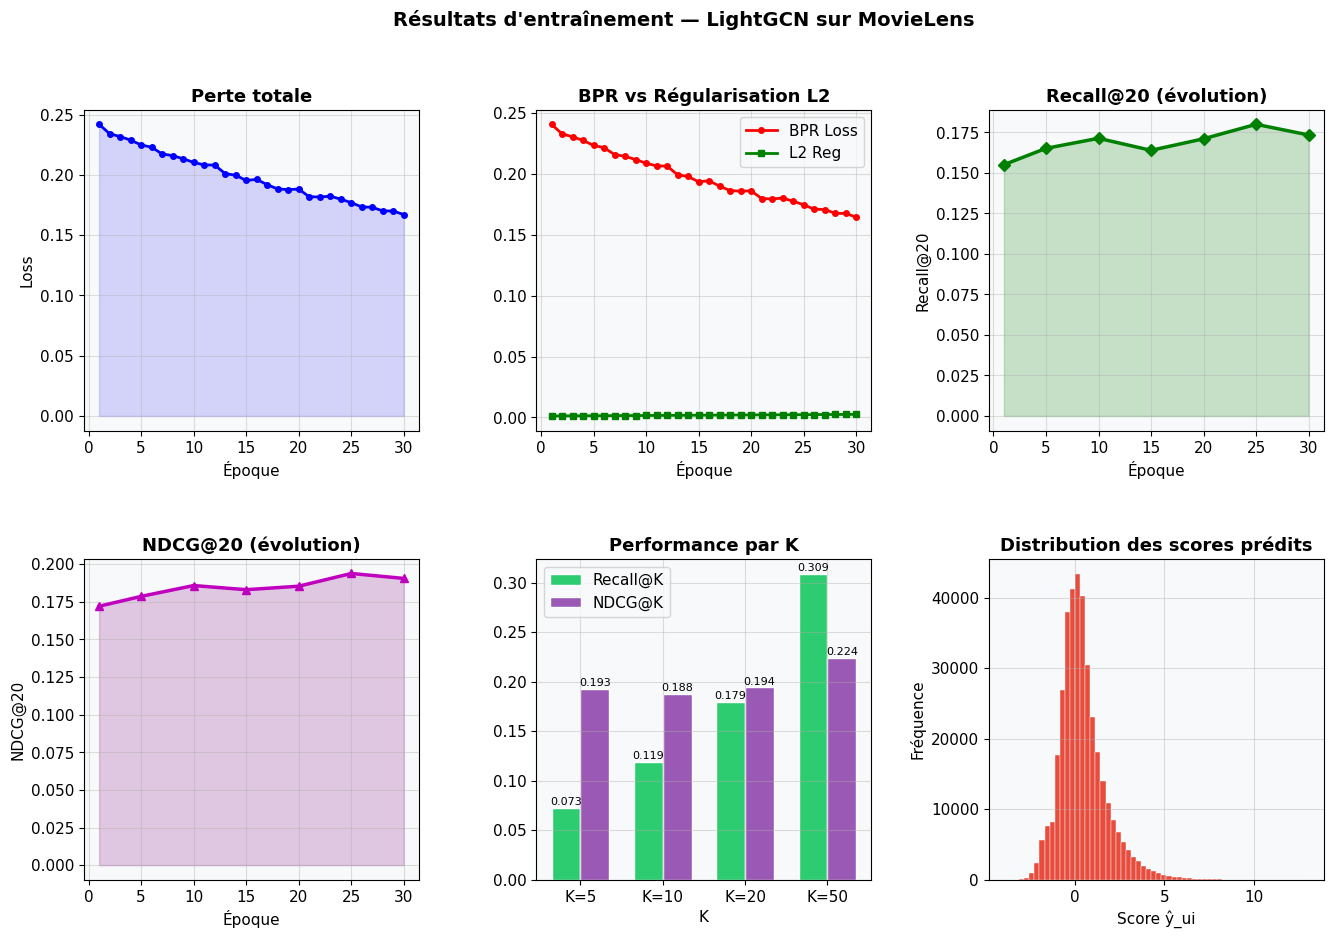

✅ Visualisations sauvegardées.


In [33]:
# ── Courbes d'entraînement ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Filtrage des époques évaluées
eval_epochs = [e for e in history['epoch'] if e % 5 == 0 or e == 1]
eval_indices = [i for i, e in enumerate(history['epoch']) if e % 5 == 0 or e == 1]
recall_filtered = [history['recall'][i] for i in eval_indices]
ndcg_filtered   = [history['ndcg'][i]   for i in eval_indices]

# Courbe de perte totale
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history['epoch'], history['loss'], 'b-o', markersize=4, linewidth=2)
ax1.set_title("Perte totale")
ax1.set_xlabel("Époque")
ax1.set_ylabel("Loss")
ax1.fill_between(history['epoch'], history['loss'],
                 alpha=0.15, color='blue')

# BPR vs Régularisation
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history['epoch'], history['bpr'], 'r-o', markersize=4,
         linewidth=2, label='BPR Loss')
ax2.plot(history['epoch'], history['reg'], 'g-s', markersize=4,
         linewidth=2, label='L2 Reg')
ax2.set_title("BPR vs Régularisation L2")
ax2.set_xlabel("Époque")
ax2.legend()

# Recall@20 au fil des époques
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(eval_epochs, recall_filtered, 'g-D', markersize=6, linewidth=2.5)
ax3.set_title("Recall@20 (évolution)")
ax3.set_xlabel("Époque")
ax3.set_ylabel("Recall@20")
ax3.fill_between(eval_epochs, recall_filtered, alpha=0.2, color='green')

# Courbe NDCG@20
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(eval_epochs, ndcg_filtered, 'm-^', markersize=6, linewidth=2.5)
ax4.set_title("NDCG@20 (évolution)")
ax4.set_xlabel("Époque")
ax4.set_ylabel("NDCG@20")
ax4.fill_between(eval_epochs, ndcg_filtered, alpha=0.2, color='purple')

# Barres de performance multi-K
ax5 = fig.add_subplot(gs[1, 1])
ks       = list(results.keys())
recalls  = [results[k]['recall'] for k in ks]
ndcgs    = [results[k]['ndcg']   for k in ks]
x = np.arange(len(ks))
w = 0.35
b1 = ax5.bar(x - w/2, recalls, w, label='Recall@K', color='#2ecc71', edgecolor='white')
b2 = ax5.bar(x + w/2, ndcgs,   w, label='NDCG@K',   color='#9b59b6', edgecolor='white')
ax5.set_title("Performance par K")
ax5.set_xlabel("K")
ax5.set_xticks(x)
ax5.set_xticklabels([f'K={k}' for k in ks])
ax5.legend()
for b in list(b1) + list(b2):
    ax5.text(b.get_x() + b.get_width()/2, b.get_height() + 0.001,
             f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Analyse de la distribution des scores (sur un sous-ensemble)
ax6 = fig.add_subplot(gs[1, 2])
with torch.no_grad():
    model.eval()
    sample_u = torch.arange(min(50, N_USERS)).to(DEVICE)
    scores_sample = model.recommend(sample_u).cpu().numpy().flatten()
ax6.hist(scores_sample, bins=60, color='#e74c3c', edgecolor='white', linewidth=0.3)
ax6.set_title("Distribution des scores prédits")
ax6.set_xlabel("Score ŷ_ui")
ax6.set_ylabel("Fréquence")

fig.suptitle("Résultats d'entraînement — LightGCN sur MovieLens",
             fontsize=14, fontweight='bold')
plt.savefig("resultats_lightgcn.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisations sauvegardées.")

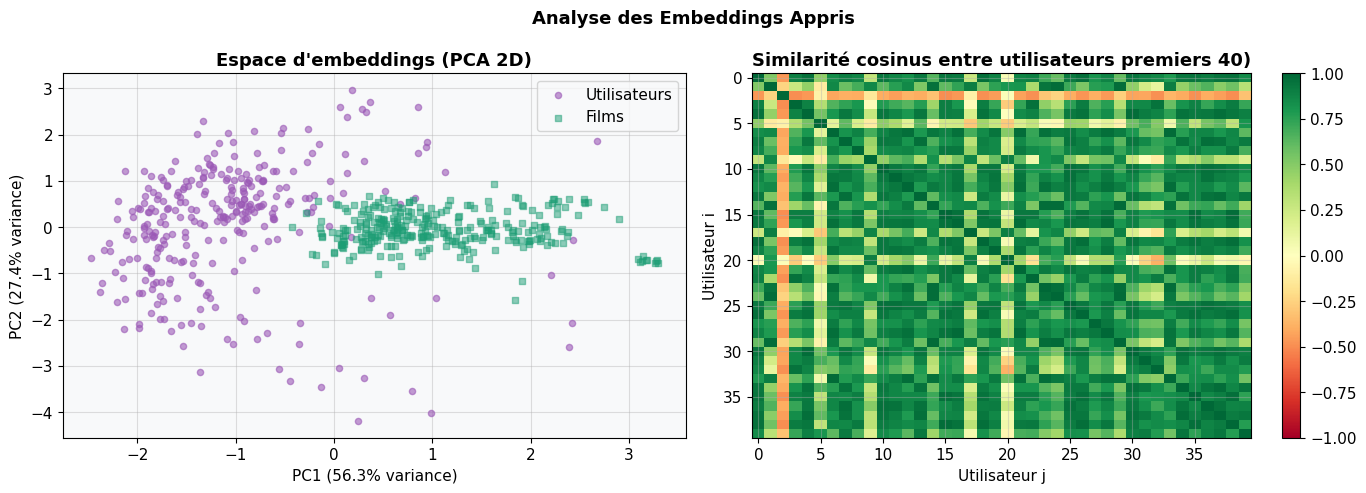

✅ Analyse PCA — variance expliquée : 83.7%


In [ ]:
# ── Analyse des embeddings (PCA 2D) ───────────────────────────────────────────
from sklearn.decomposition import PCA

with torch.no_grad():
    model.eval()
    user_emb_np = model.user_embed.weight.cpu().numpy()
    item_emb_np = model.item_embed.weight.cpu().numpy()

pca = PCA(n_components=2, random_state=SEED)
all_emb = np.vstack([user_emb_np[:300], item_emb_np[:300]])
all_2d  = pca.fit_transform(all_emb)

u_2d = all_2d[:300]
i_2d = all_2d[300:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.scatter(u_2d[:, 0], u_2d[:, 1], s=20, c='#9b59b6', alpha=0.6,
            label='Utilisateurs', zorder=2)
ax1.scatter(i_2d[:, 0], i_2d[:, 1], s=15, c='#1D9E75', alpha=0.5,
            marker='s', label='Films', zorder=2)
ax1.set_title("Espace d'embeddings (PCA 2D)")
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax1.legend()

# Heatmap de similarité cosinus (50 premiers users)
from sklearn.metrics.pairwise import cosine_similarity
n_show = 40
sim_matrix = cosine_similarity(user_emb_np[:n_show])

ax2 = axes[1]
im = ax2.imshow(sim_matrix, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax2.set_title(f"Similarité cosinus entre utilisateurs premiers {n_show})")
ax2.set_xlabel("Utilisateur j")
ax2.set_ylabel("Utilisateur i")
plt.colorbar(im, ax=ax2)

plt.suptitle("Analyse des Embeddings Appris", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("embeddings_analyse.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Analyse PCA — variance expliquée : {sum(pca.explained_variance_ratio_)*100:.1f}%")

<a id='section10'></a>
## 10. Génération de Recommandations Top-K

Voyons concrètement ce que recommande notre modèle à des utilisateurs réels.

In [ ]:
def get_top_k_recommendations(model, user_idx, n_items, user_pos_items,
                               movies_df, item2idx, k=10):
    """
    Génère les Top-K recommandations pour un utilisateur.

    Retourne un DataFrame avec les films recommandés et leurs scores.
    """
    model.eval()
    with torch.no_grad():
        u_tensor = torch.LongTensor([user_idx]).to(DEVICE)
        scores   = model.recommend(u_tensor).squeeze(0).cpu().numpy()

    # Masquer les items déjà vus
    for pos in user_pos_items.get(user_idx, []):
        scores[pos] = -1e9

    top_k_indices = np.argsort(-scores)[:k]

    # Reconstruction : index → movieId → titre
    idx2item_local = {v: k for k, v in item2idx.items()}
    movie_id_to_title = dict(zip(movies_df.index, movies_df['title']))

    recs = []
    for rank, item_idx in enumerate(top_k_indices, 1):
        movie_id = idx2item_local.get(item_idx, -1)
        title    = movie_id_to_title.get(movie_id, f"Film #{movie_id}")
        score    = scores[item_idx]
        recs.append({'Rang': rank, 'Titre': title, 'Score': round(float(score), 4)})

    return pd.DataFrame(recs)


def get_user_history(user_idx, user_pos_items, movies_df, item2idx, n=5):
    """Affiche les films vus par un utilisateur."""
    idx2item_local   = {v: k for k, v in item2idx.items()}
    movie_id_to_title = dict(zip(movies_df.index, movies_df['title']))

    seen_items = list(user_pos_items.get(user_idx, set()))[:n]
    titles = [movie_id_to_title.get(idx2item_local.get(i, -1), "?") for i in seen_items]
    return titles


# ── Démons

In [ ]:
# ── Tableau de bord final ─────────────────────────────────────────────────────
print("\n")
print("╔" + "═"*60 + "╗")
print("║" + "  BILAN FINAL — LIGHTGCN SUR MOVIELENS".center(60) + "║")
print("╠" + "═"*60 + "╣")
print(f"║  Dataset       : MovieLens small{'':20}║")
print(f"║  Utilisateurs  : {N_USERS:<40}║")
print(f"║  Films         : {N_ITEMS:<40}║")
print(f"║  Interactions  : {len(train_df):,}{'':<34}║")
print("╠" + "═"*60 + "╣")
print(f"║  Architecture  : LightGCN (K={N_LAYERS} couches, d={EMBED_DIM}){'':16}║")
print(f"║  Paramètres    : {model.count_parameters():,}{'':<37}║")
print(f"║  Entraînement  : {EPOCHS} époques, BPR + L2{'':<21}║")
print("╠" + "═"*60 + "╣")
for k in [5, 10, 20]:
    r = results[k]['recall']
    n = results[k]['ndcg']
    print(f"║  Recall@{k:<2}     : {r:.4f}    NDCG@{k:<2} : {n:.4f}{'':15}║")
print("╚" + "═"*60 + "╝")



╔════════════════════════════════════════════════════════════╗
║             BILAN FINAL — LIGHTGCN SUR MOVIELENS           ║
╠════════════════════════════════════════════════════════════╣
║  Dataset       : MovieLens small                    ║
║  Utilisateurs  : 609                                     ║
║  Films         : 7363                                    ║
║  Interactions  : 49,619                                  ║
╠════════════════════════════════════════════════════════════╣
║  Architecture  : LightGCN (K=3 couches, d=64)                ║
║  Paramètres    : 510,208                                     ║
║  Entraînement  : 30 époques, BPR + L2                     ║
╠════════════════════════════════════════════════════════════╣
║  Recall@5      : 0.0591    NDCG@5  : 0.1675               ║
║  Recall@10     : 0.1051    NDCG@10 : 0.1650               ║
║  Recall@20     : 0.1546    NDCG@20 : 0.1702               ║
╚════════════════════════════════════════════════════════════╝


---

## Conclusion

Dans ce TP, nous avons construit de A à Z un système de recommandation moderne basé sur **LightGCN** :

1. **Graphe biparti** : représentation des interactions utilisateur-film comme un graphe
2. **Propagation d'embeddings** : chaque utilisateur/film agrège l'information de ses voisins sur K couches
3. **Perte BPR** : apprentissage par comparaison paires positives/négatives
4. **Évaluation rigoureuse** : Recall@K et NDCG@K sur un test set hold-out

### Points clés de LightGCN
- **Simplicité** : pas de transformation linéaire ni d'activation → moins de paramètres, plus rapide
- **Efficacité** : la propagation multi-couches capture des signaux collaboratifs de haut niveau
- **Scalabilité** : fonctionne sur de très grands graphes grâce aux matrices sparse

### Pistes d'amélioration
- Augmenter le nombre de couches K et la dimension d'embedding
- Utiliser un scheduler de learning rate (cosine annealing)
- Explorer LightGCN++ ou NGCF pour des architectures plus expressives
- Intégrer des features de contenu (genres, acteurs) — approche hybride



**École Nationale Supérieure Polytechnique de Yaoundé — ANI-IA 4 — 2025/2026**